<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/Calculus/sympy/sympy_02_bayes_theorem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$P(Cancer|Coffee) = \frac{P(Coffee|Cancer) \cdot P(Cancer)}{P(Coffee)}$$

In [ ]:
p_coffee_drinker = .65
p_cancer = .005
p_coffee_drinker_given_cancer = .85

p_cancer_given_coffee_drinker = p_coffee_drinker_given_cancer * p_cancer / p_coffee_drinker

# prints 0.006538461538461539
print(p_cancer_given_coffee_drinker)

0.006538461538461539


이항분포(Binomial Distribution)의 확률질량함수(PMF, Probability Mass Function)를 계산

- "성공 확률이 90%인 어떤 일을 총 10번 반복했을 때, 성공 횟수(0번부터 10번까지)에 따라 각각 확률이 어떻게 되는지"

In [ ]:
from scipy.stats import binom

n = 10
p = 0.9

for k in range(n + 1):
    probability = binom.pmf(k, n, p)
    print(f"{k} - {probability}")

0 - 9.999999999999977e-11
1 - 8.999999999999978e-09
2 - 3.6449999999999943e-07
3 - 8.747999999999991e-06
4 - 0.00013778099999999974
5 - 0.0014880347999999982
6 - 0.011160260999999996
7 - 0.05739562799999997
8 - 0.1937102444999998
9 - 0.38742048899999976
10 - 0.3486784401000001


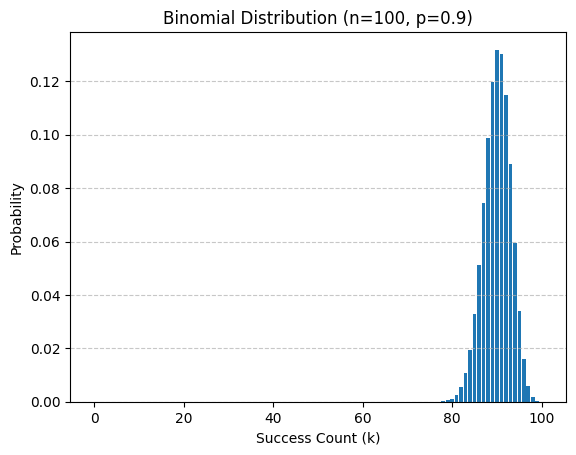

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 100
p = 0.9

probability_list = []

for k in range(n + 1):
    probability = binom.pmf(k, n, p)
    probability_list.append(probability)

plt.bar(range(n + 1), probability_list)
plt.xlabel('Success Count (k)')
plt.ylabel('Probability')
plt.title(f'Binomial Distribution (n={n}, p={p})')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 정규분포
- 중심극한정리(Central Limit Theorem)에 따르면, 이항분포에서 시행 횟수 $n$이 충분히 커지면 그 분포는 정규분포(Normal Distribution)에 가까워지며
- Scipy의 norm 라이브러리를 사용하여, 기존 이항분포 그래프 위에 정규분포 곡선(확률밀도함수, PDF)을 시각화

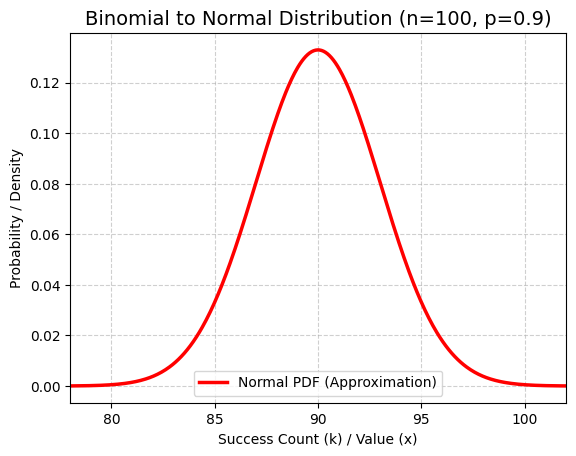

In [ ]:
import numpy as np
from scipy.stats import norm

# 이항분포의 평균(μ)과 표준편차(σ) 계산
mu = n * p                          # 100 * 0.9 = 90
sigma = np.sqrt(n * p * (1 - p))    # sqrt(100 * 0.9 * 0.1) = 3

# 3. 정규분포(Normal Distribution) 연속 곡선 추가
# 그래프를 매끄럽게 그리기 위해 x축을 촘촘하게 나눕니다 (예: 70부터 110까지)
x_continuous = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
# 정규분포의 확률밀도함수(PDF) 계산
normal_pdf = norm.pdf(x_continuous, mu, sigma)

# 정규분포는 연속확률분포이므로 매끄러운 곡선으로 표현합니다.
plt.plot(x_continuous, normal_pdf, label='Normal PDF (Approximation)', color='red', linewidth=2.5)


# 4. 그래프 꾸미기
plt.title(f'Binomial to Normal Distribution (n={n}, p={p})', fontsize=14)
plt.xlabel('Success Count (k) / Value (x)')
plt.ylabel('Probability / Density')
plt.xlim(mu - 4*sigma, mu + 4*sigma) # 변동이 있는 주요 구간만 확대해서 보기
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()